# POC simulation v3 — DAG with two IVs, mediation, L and U

This version fixes the original notebook structure and matches the DAG:

- `Z1 -> A`
- `Z2 -> M`
- `L -> A, M, Y` measured confounder
- `U -> A, M, Y` unmeasured confounder
- `A -> M`, `A -> Y`, `M -> Y`

The notebook computes:

1. True total, direct and indirect risk differences / NNTs from the known data-generating mechanism.
2. Crude unadjusted estimates.
3. L-adjusted naive g-computation estimates.
4. A simple two-IV G-estimation style estimator for direct and indirect effects.

Important: the IV/G-estimation section is a simulation prototype, not a final identification proof.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.special import expit
from scipy.optimize import root, root_scalar
import statsmodels.api as sm

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

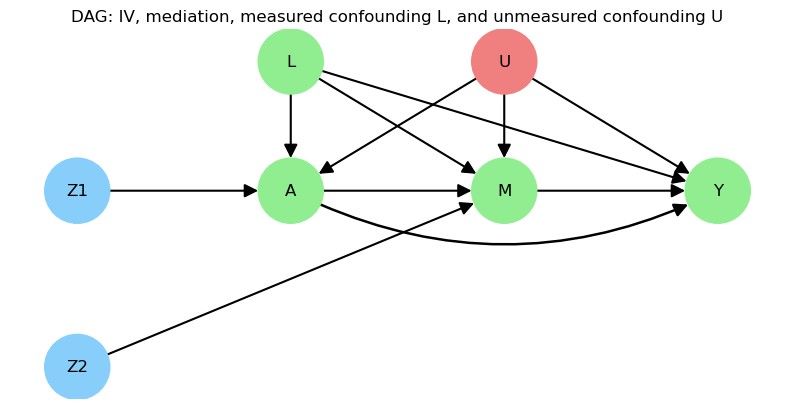

In [2]:

def draw_dag():
    G = nx.DiGraph()

    edges = [
        ("Z1", "A"), ("Z2", "M"),
        ("L", "A"), ("L", "M"), ("L", "Y"),
        ("U", "A"), ("U", "M"), ("U", "Y"),
        ("A", "M"),
        ("M", "Y")
    ]

    curved_edges = [
        ("A", "Y")
    ]

    G.add_edges_from(edges + curved_edges)

    pos = {
        "Z1": (0.0, 1.5),
        "Z2": (0.0, 0.0),

        "L": (2.0, 2.6),
        "A": (2.0, 1.5),

        "U": (4.0, 2.6),
        "M": (4.0, 1.5),

        "Y": (6.0, 1.5),
    }

    colors = {
        "Z1": "lightskyblue",
        "Z2": "lightskyblue",
        "U": "lightcoral"
    }

    node_colors = [colors.get(n, "lightgreen") for n in G.nodes()]

    plt.figure(figsize=(10, 4.8))

    # Draw nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=2200
    )

    # Draw labels
    nx.draw_networkx_labels(
        G, pos,
        font_size=12
    )

    # Draw regular edges
    nx.draw_networkx_edges(
        G, pos,
        edgelist=edges,
        arrows=True,
        arrowsize=20,
        width=1.5,
        node_size=2200,
        connectionstyle="arc3,rad=0.0"
    )

    # Draw curved A -> Y edge
    nx.draw_networkx_edges(
        G, pos,
        edgelist=curved_edges,
        arrows=True,
        arrowsize=20,
        width=1.8,
        node_size=2200,
        connectionstyle="arc3,rad=0.25"
    )

    plt.title("DAG: IV, mediation, measured confounding L, and unmeasured confounding U")
    plt.axis("off")
    plt.show()


draw_dag()

## Data-generating mechanism

`with_u=True` creates unmeasured confounding through `U`.

`with_u=False` removes the effect of `U`, but measured confounding through `L` remains.

`Z1` is an instrument for the exposure `A`.

`Z2` is an instrument for the mediator `M`.

In [3]:
DGM = {
    "A": {"intercept": -1.0, "Z1": 1.4, "L": 0.6, "U": 0.9},
    "M": {"intercept": -1.6, "A": 1.2, "Z2": 1.3, "L": 0.5, "U": 0.8},
    "Y": {"intercept": -3.0, "A": 0.8, "M": 1.4, "L": -0.7, "U": 1.1},
}


def simulate_data(N=5000, with_u=True, seed=None):
    rng = np.random.default_rng(seed)

    Z1 = rng.binomial(1, 0.5, N) # 0 or 1
    Z2 = rng.binomial(1, 0.5, N) # 0 or 1
    L = rng.normal(0.5, 0.5, N)
    U = rng.normal(0, 1, N)

    uA = DGM["A"]["U"] if with_u else 0.0
    uM = DGM["M"]["U"] if with_u else 0.0
    uY = DGM["Y"]["U"] if with_u else 0.0

    # Stractural Equations
    pA = expit(DGM["A"]["intercept"] + DGM["A"]["Z1"] * Z1 + DGM["A"]["L"] * L + uA * U)
    A = rng.binomial(1, pA)

    pM = expit(DGM["M"]["intercept"] + DGM["M"]["A"] * A + DGM["M"]["Z2"] * Z2 + DGM["M"]["L"] * L + uM * U)
    M = rng.binomial(1, pM)

    pY = expit(DGM["Y"]["intercept"] + DGM["Y"]["A"] * A + DGM["Y"]["M"] * M + DGM["Y"]["L"] * L + uY * U)
    Y = rng.binomial(1, pY)

    return pd.DataFrame({"Z1": Z1, "Z2": Z2, "L": L, "U": U, "A": A, "M": M, "Y": Y})


def nnt_from_rd(rd, eps=1e-8):
    if abs(rd) < eps:
        return np.nan
    return 1.0 / rd


def add_nnt_cols(out):
    return {
        **out,
        "total_nnt": nnt_from_rd(out["total_rd"]),
        "direct_nnt": nnt_from_rd(out["direct_rd"]),
        "indirect_nnt": nnt_from_rd(out["indirect_rd"]),
    }

## True total, direct and indirect effects

Definitions on the risk-difference scale:

`TE = E[Y(1, M(1))] - E[Y(0, M(0))]`

`NDE = E[Y(1, M(0))] - E[Y(0, M(0))]`

`NIE = E[Y(1, M(1))] - E[Y(1, M(0))]`

Then:

`NNT_total = 1 / TE`, `NNT_direct = 1 / NDE`, `NNT_indirect = 1 / NIE`.

In [4]:
# This cell compute the true total, direct, and indirect causal effects 
# by averaging counterfactual outcome probabilities over the simulated population (mc - monte carlo).

# GROUND TRUTH
# Calculating the true effects from the known simulation model.
def true_effects_mc(df, with_u=True):
    # Once we intervene and set treatment to A=1 or A=0, Z1 is no longer needed.
    L = df["L"].to_numpy()
    U = df["U"].to_numpy()
    Z2 = df["Z2"].to_numpy()  # Z2 affects the natural mediator distribution
    

    uM = DGM["M"]["U"] if with_u else 0.0
    uY = DGM["Y"]["U"] if with_u else 0.0
    
    # Mediator probability function
    def p_m(a):
        return expit(DGM["M"]["intercept"] + DGM["M"]["A"] * a + DGM["M"]["Z2"] * Z2 + DGM["M"]["L"] * L + uM * U)
    
    # Outcome probability function
    def p_y(a, m):
        return expit(DGM["Y"]["intercept"] + DGM["Y"]["A"] * a + DGM["Y"]["M"] * m + DGM["Y"]["L"] * L + uY * U)
    
    # pM1 = mediator probability if everyone received treatment
    # pM0 = mediator probability if nobody received treatment
    pM1 = p_m(1)
    pM0 = p_m(0)
    

    EY_1_M1 = np.mean(p_y(1, 1) * pM1 + p_y(1, 0) * (1 - pM1))
    EY_0_M0 = np.mean(p_y(0, 1) * pM0 + p_y(0, 0) * (1 - pM0))
    EY_1_M0 = np.mean(p_y(1, 1) * pM0 + p_y(1, 0) * (1 - pM0))

    return add_nnt_cols({
        "total_rd": EY_1_M1 - EY_0_M0,
        "direct_rd": EY_1_M0 - EY_0_M0,
        "indirect_rd": EY_1_M1 - EY_1_M0,
    })

## Naive estimators

`crude_unadjusted_effects` intentionally does **not** adjust for `L` or `U`.

`naive_gcomp_effects(adjust_L=True)` adjusts for measured `L`, but not for unmeasured `U`.

In [5]:
def _fit_logit(y, X):
    X = sm.add_constant(X, has_constant="add")
    return sm.Logit(y, X).fit(disp=0, maxiter=200)

# Does not adjust for L and U.
# Baseline showing how biased the results can be, overall NNT.
def crude_unadjusted_effects(df):
    rd = df.loc[df["A"] == 1, "Y"].mean() - df.loc[df["A"] == 0, "Y"].mean()
    return {"total_rd": rd, "total_nnt": nnt_from_rd(rd)}

# if L true adjust for L
# Adjusting just for L, ignoring U.
def naive_gcomp_effects(df, adjust_L=True):
    m_covars = ["A"] + (["L"] if adjust_L else [])
    y_covars = ["A", "M"] + (["L"] if adjust_L else [])
    
    # Fitting mediator and outcome models
    fit_m = _fit_logit(df["M"], df[m_covars])
    fit_y = _fit_logit(df["Y"], df[y_covars])

    def pred_m(a):
        X = df[m_covars].copy()
        X["A"] = a
        X = sm.add_constant(X, has_constant="add")
        return fit_m.predict(X)

    def pred_y(a, m):
        X = df[y_covars].copy()
        X["A"] = a
        X["M"] = m
        X = sm.add_constant(X, has_constant="add")
        return fit_y.predict(X)

    pM1 = pred_m(1)
    pM0 = pred_m(0)

    EY_1_M1 = np.mean(pred_y(1, 1) * pM1 + pred_y(1, 0) * (1 - pM1))
    EY_0_M0 = np.mean(pred_y(0, 1) * pM0 + pred_y(0, 0) * (1 - pM0))
    EY_1_M0 = np.mean(pred_y(1, 1) * pM0 + pred_y(1, 0) * (1 - pM0))

    # risk difference
    return add_nnt_cols({
        "total_rd": EY_1_M1 - EY_0_M0,
        "direct_rd": EY_1_M0 - EY_0_M0,
        "indirect_rd": EY_1_M1 - EY_1_M0,
    })

## Two-IV G-estimation style estimator

This uses:

- `Z1` as the instrument for `A`.
- `Z2` as the instrument for `M`.

It estimates two outcome blips, one for `A` and one for `M`, by solving two orthogonality equations.
It also estimates the effect of `A` on `M` using `Z1`.

This is a practical POC aligned with the simulation, but it should be presented as an estimator prototype unless the final assumptions/proof are written formally.

In [6]:
# This is a helper function for solving an equation with one unknown parameter.
def _solve_one_dim(fun, x0=0.0):
    # Try a robust bracket first; fall back to root if needed.
    grid = np.linspace(-8, 8, 81)
    vals = [fun(x) for x in grid]
    for lo, hi, flo, fhi in zip(grid[:-1], grid[1:], vals[:-1], vals[1:]):
        if np.isfinite(flo) and np.isfinite(fhi) and flo * fhi <= 0:
            return root_scalar(fun, bracket=[lo, hi]).root
    return root(lambda z: [fun(z[0])], [x0]).x[0]

# The goal is to handle the fact that U is unmeasured.
def iv_g_estimation_effects(df, adjust_L=True):
    controls = ["L"] if adjust_L else []

    # 1) Mediator blip: remove the effect of A on M using Z1 as IV.
    m_cols = ["A", "Z1", "Z2"] + controls
    fit_m = _fit_logit(df["M"], df[m_cols])
    Xm = sm.add_constant(df[m_cols], has_constant="add")
    lp_m = np.asarray(Xm @ fit_m.params)
    A = df["A"].to_numpy()
    Z1 = df["Z1"].to_numpy()
    # If transformed M is independent of Z1, then its covariance with centered Z1 should be zero.
    z1c = Z1 - Z1.mean()

    def eq_theta(theta):
        # lp_m = model prediction with observed A effect included
        # lp_m - theta*A = model prediction after subtracting the causal effect of A
        h0 = expit(lp_m - theta * A)
        return np.sum(z1c * h0)
    
    # Find theta such that after removing the effect of A on M, the transformed mediator is no longer associated with Z1.
    theta = float(_solve_one_dim(eq_theta, x0=0.0))
    pM0 = expit(lp_m - theta * A)
    pM1 = expit(lp_m + theta * (1 - A))

    # 2) Outcome blips: remove direct A effect and M effect using Z1 and Z2.
    y_cols = ["A", "M", "Z1", "Z2"] + controls
    fit_y = _fit_logit(df["Y"], df[y_cols])
    Xy = sm.add_constant(df[y_cols], has_constant="add")
    # lp_y = prediction under observed A and observed M
    lp_y = np.asarray(Xy @ fit_y.params)
    M = df["M"].to_numpy()
    Z2 = df["Z2"].to_numpy()
    z2c = Z2 - Z2.mean()

    # After removing the effects of A and M,
    # the transformed outcome should not be associated with Z1 or Z2.
    def equations(par):
        # psi_a = direct effect of A on Y
        # psi_m = effect of M on Y
        psi_a, psi_m = par
        h00 = expit(lp_y - psi_a * A - psi_m * M)
        return np.array([
            np.sum(z1c * h00),
            np.sum(z2c * h00),
        ])

    sol = root(equations, x0=np.array([0.0, 0.0]))
    psi_a, psi_m = sol.x

    def p_y_cf(a, m):
        return expit(lp_y + psi_a * (a - A) + psi_m * (m - M))

    EY_1_M1 = np.mean(p_y_cf(1, 1) * pM1 + p_y_cf(1, 0) * (1 - pM1))
    EY_0_M0 = np.mean(p_y_cf(0, 1) * pM0 + p_y_cf(0, 0) * (1 - pM0))
    EY_1_M0 = np.mean(p_y_cf(1, 1) * pM0 + p_y_cf(1, 0) * (1 - pM0))

    out = add_nnt_cols({
        "total_rd": EY_1_M1 - EY_0_M0,
        "direct_rd": EY_1_M0 - EY_0_M0,
        "indirect_rd": EY_1_M1 - EY_1_M0,
    })
    out.update({"theta_A_to_M": theta, "psi_A_direct": psi_a, "psi_M_to_Y": psi_m, "root_success": bool(sol.success)})
    return out

In [7]:
def one_run_table(N=10000, with_u=True, seed=1):
    df = simulate_data(N=N, with_u=with_u, seed=seed)
    methods = {
        "true": true_effects_mc(df, with_u=with_u),
        "crude_unadjusted_total_only": crude_unadjusted_effects(df),
        "naive_unadjusted_mediation": naive_gcomp_effects(df, adjust_L=False),
        "naive_L_adjusted_mediation": naive_gcomp_effects(df, adjust_L=True),
        
        # This version tries to handle the unmeasured confounder U using the instruments Z1 and Z2,
        # but it ignores the measured confounder L.
        "iv_g_unadjusted_L": iv_g_estimation_effects(df, adjust_L=False),
        
        # This version uses the instruments Z1 and Z2 and also adjusts for the measured confounder L.
        "iv_g_L_adjusted": iv_g_estimation_effects(df, adjust_L=True),
    }
    return pd.DataFrame(methods).T

one_run_table(N=100000, with_u=True, seed=10).round(3)

,total_rd,direct_rd,indirect_rd,total_nnt,direct_nnt,indirect_nnt,theta_A_to_M,psi_A_direct,psi_M_to_Y,root_success
true,0.118475,0.076228,0.042247,8.440593,13.118466,23.670505,NaN,NaN,NaN,NaN
crude_unadjusted_total_only,0.206418,NaN,NaN,4.84455,NaN,NaN,NaN,NaN,NaN,NaN
naive_unadjusted_mediation,0.206418,0.106279,0.100138,4.84455,9.409162,9.986207,NaN,NaN,NaN,NaN
naive_L_adjusted_mediation,0.214833,0.112526,0.102307,4.654772,8.886808,9.774505,NaN,NaN,NaN,NaN
iv_g_unadjusted_L,0.128009,0.084161,0.043848,7.811925,11.881987,22.805844,1.076654,0.778718,1.219408,True
iv_g_L_adjusted,0.127626,0.083931,0.043695,7.83537,11.914511,22.88585,1.083465,0.791315,1.2409,True


In [8]:
def run_many_simulations(n_rep=50, N=5000, with_u=True, base_seed=1000):
    rows = []
    for r in range(n_rep):
        df = simulate_data(N=N, with_u=with_u, seed=base_seed + r)
        scenario = "With U" if with_u else "Without U"
        estimators = {
            "true": true_effects_mc(df, with_u=with_u),
            "naive_unadjusted": naive_gcomp_effects(df, adjust_L=False),
            "naive_L_adjusted": naive_gcomp_effects(df, adjust_L=True),
            "iv_g_unadjusted_L": iv_g_estimation_effects(df, adjust_L=False),
            "iv_g_L_adjusted": iv_g_estimation_effects(df, adjust_L=True),
        }
        for name, vals in estimators.items():
            rows.append({"scenario": scenario, "rep": r + 1, "estimator": name, **vals})
    return pd.DataFrame(rows)

results = pd.concat([
    run_many_simulations(n_rep=30, N=100000, with_u=False, base_seed=10),
    run_many_simulations(n_rep=30, N=100000, with_u=True, base_seed=10),
], ignore_index=True)

summary = (
    results.groupby(["scenario", "estimator"])[["total_rd", "direct_rd", "indirect_rd", "total_nnt", "direct_nnt", "indirect_nnt"]]
    .agg(["mean", "std"])
    .round(3)
)
summary

total_rd        direct_rd        indirect_rd  \
                                mean    std      mean    std        mean   
scenario  estimator                                                        
With U    iv_g_L_adjusted      0.115  0.009     0.075  0.008       0.041   
          iv_g_unadjusted_L    0.116  0.009     0.075  0.008       0.041   
          naive_L_adjusted     0.217  0.003     0.115  0.003       0.102   
          naive_unadjusted     0.209  0.003     0.109  0.003       0.100   
          true                 0.119  0.000     0.076  0.000       0.042   
Without U iv_g_L_adjusted      0.112  0.006     0.068  0.005       0.044   
          iv_g_unadjusted_L    0.113  0.006     0.068  0.006       0.045   
          naive_L_adjusted     0.111  0.002     0.066  0.002       0.045   
          naive_unadjusted     0.104  0.002     0.060  0.002       0.043   
          true                 0.111  0.000     0.066  0.000       0.044   

                                   total_nnt        direct_nnt         \
                               std      mean    std       mean    std   
scenario  estimator                                                     
With U    iv_g_L_adjusted    0.003     8.728  0.718     13.535  1.497   
          iv_g_unadjusted_L  0.003     8.708  0.713     13.529  1.503   
          naive_L_adjusted   0.001     4.607  0.061      8.707  0.201   
          naive_unadjusted   0.001     4.792  0.068      9.204  0.225   
          true               0.000     8.420  0.015     13.079  0.025   
Without U iv_g_L_adjusted    0.003     8.938  0.456     14.825  1.201   
          iv_g_unadjusted_L  0.003     8.873  0.468     14.711  1.225   
          naive_L_adjusted   0.001     9.022  0.192     15.085  0.508   
          naive_unadjusted   0.001     9.642  0.210     16.564  0.594   
          true               0.000     9.045  0.006     15.119  0.012   

                            indirect_nnt         
                                    mean    std  
scenario  estimator                              
With U    iv_g_L_adjusted         24.781  1.946  
          iv_g_unadjusted_L       24.645  1.917  
          naive_L_adjusted         9.789  0.141  
          naive_unadjusted        10.001  0.150  
          true                    23.637  0.038  
Without U iv_g_L_adjusted         22.659  1.352  
          iv_g_unadjusted_L       22.513  1.339  
          naive_L_adjusted        22.468  0.439  
          naive_unadjusted        23.095  0.454  
          true                    22.515  0.013

When U is absent, standard L-adjusted g-computation is close to the true effects.<br>

When U is present, naive g-computation remains biased because it cannot adjust for U.<br>

The IV/G-estimation approach attempts to reduce this bias by using Z1 and Z2 as instruments.<br> 

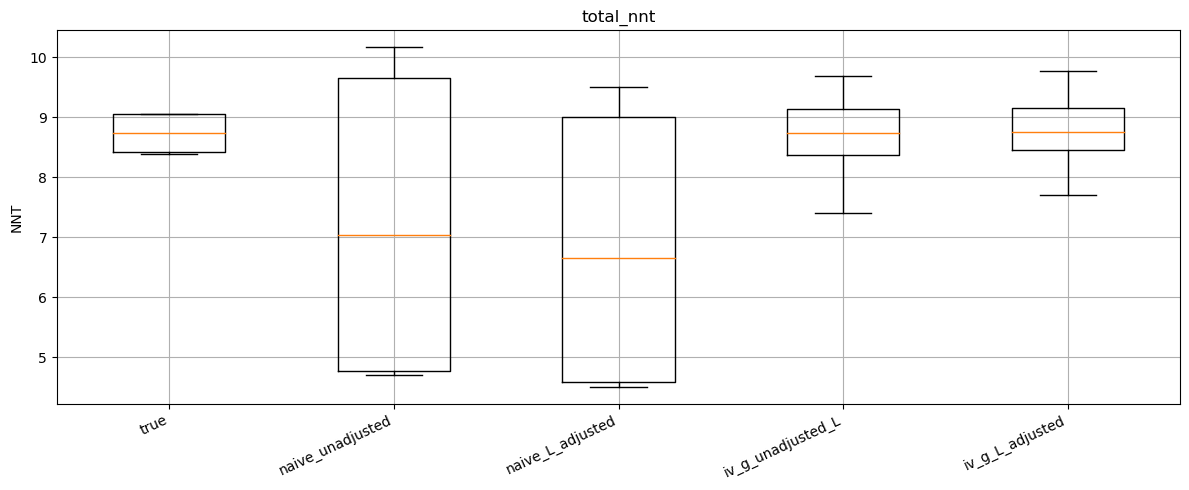

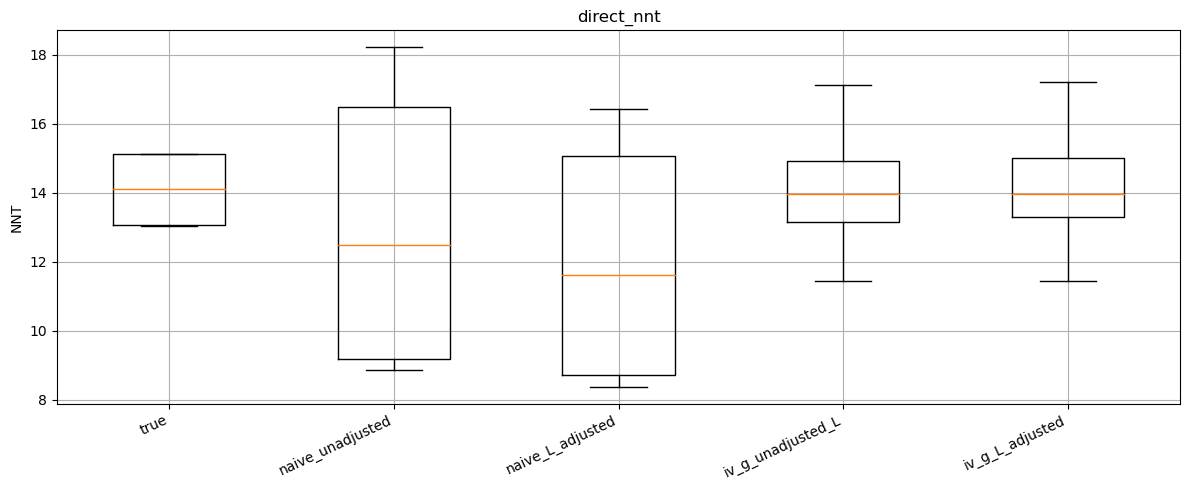

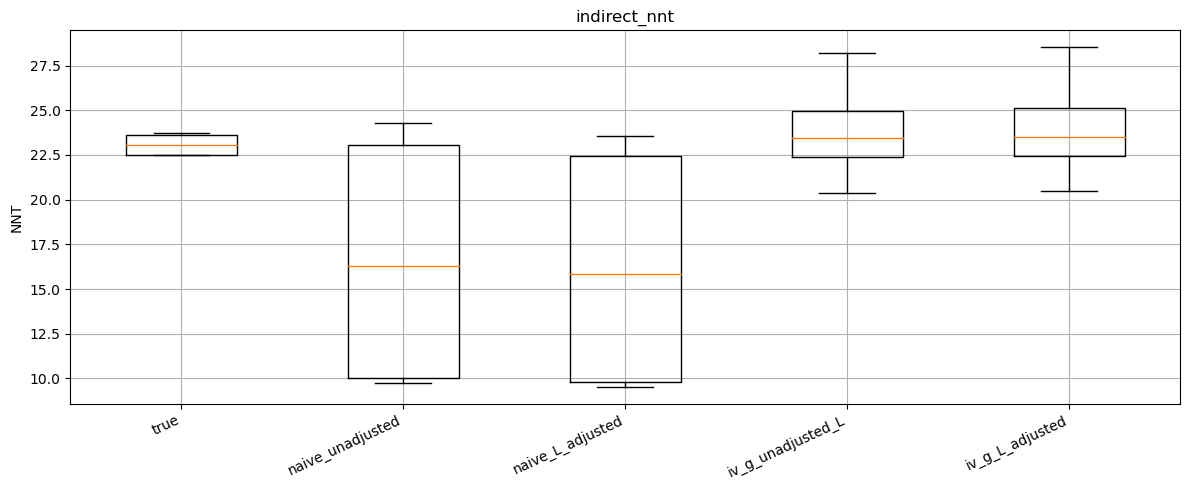

In [9]:
# Plot NNT distributions. Extreme NNT values can happen when an estimated RD is close to zero,
# so the plot clips the y-axis for readability.
plot_df = results.melt(
    id_vars=["scenario", "rep", "estimator"],
    value_vars=["total_nnt", "direct_nnt", "indirect_nnt"],
    var_name="quantity",
    value_name="nnt"
).replace([np.inf, -np.inf], np.nan).dropna()

for quantity in ["total_nnt", "direct_nnt", "indirect_nnt"]:
    subset = plot_df[plot_df["quantity"] == quantity]
    labels = ["true", "naive_unadjusted", "naive_L_adjusted", "iv_g_unadjusted_L", "iv_g_L_adjusted"]
    data = [subset.loc[subset["estimator"] == lab, "nnt"].values for lab in labels]
    plt.figure(figsize=(12, 5))
    plt.boxplot(data, labels=labels, showfliers=False)
    plt.title(quantity)
    plt.ylabel("NNT")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

The simulation demonstrates that when all confounders are measured, L-adjusted g-computation accurately estimates the total, direct, and indirect effects.<br>
However, when an unmeasured confounder U affects the treatment, mediator, and outcome, naive g-computation becomes biased.<br>
The IV/G-estimation-style estimator, which uses Z1 and Z2 as instruments while adjusting for L, produces estimates much closer to the true causal effects.<br>
These results support the motivation for using instrumental-variable-based G-estimation methods when estimating direct and indirect NNT-style measures in observational studies with unmeasured confounding.